# New Song Prediction and Model Evaluation
In this section, we have 10 songs in recommend.csv that represent what a hypothetical
user has been listening to. Our task here is to  use our trained KMeans model to assign each of the 10 songs
to one of our 8 clusters and generate personalized recommendations.

The recommend.csv file contains a column called `topic` which is
the actual lyrical label for each song (e.g. violence, sadness,
romantic, world/life). This gives us a way to evaluate our model by  comparing what our KMeans model predicted versus what the true topic label says. If our clusters align well with the true topic labels it means our unsupervised model discovered real structure in the data without ever being told what the correct answer was.


In [50]:
# Importing necessary libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.metrics import confusion_matrix, classification_report

import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')

print("Libraries loaded.")

Libraries loaded.


In [51]:
# Loading all the datasets we will be using in the project

# Load the 10 test songs — keep ALL columns including topic for evaluation
df_test = pd.read_csv('/Users/sa03/Desktop/Music Recommendation Algorithm/Dataset/music_rec/recommend - recommend.csv')
df_test = df_test.rename(columns={'Unnamed: 0': 'song_id'})
df_test = df_test.set_index('song_id')

# Load the trained KMeans model
model = joblib.load('/Users/sa03/Desktop/Music Recommendation Algorithm/Dataset/music_rec/kmeans_model.pkl')

# Load the StandardScaler — must reuse this exact scaler
scaler = joblib.load('/Users/sa03/Desktop/Music Recommendation Algorithm/Dataset/music_rec/scaler.pkl')

# Load training songs with cluster labels
df_train_labeled = pd.read_csv('/Users/sa03/Desktop/Music Recommendation Algorithm/Dataset/music_rec/train_with_clusters.csv')

# Load cleaned training features for column alignment
df_train_features = pd.read_csv('/Users/sa03/Desktop/Music Recommendation Algorithm/Dataset/music_rec/train_cleaned_unscaled.csv', index_col=0)

# Confirm everything loaded
print(f"Test songs:                 {df_test.shape[0]}")
print(f"Test columns:               {df_test.shape[1]}")
print(f"Training songs with labels: {df_train_labeled.shape[0]}")
print(f"Scaler features:            {len(scaler.feature_names_in_)}")
print()
print("Test songs and their TRUE topic labels:")
print()
print(df_test[['artist_name', 'track_name', 'genre', 'topic']].to_string())

Test songs:                 10
Test columns:               24
Training songs with labels: 28362
Scaler features:            17

Test songs and their TRUE topic labels:

                      artist_name            track_name    genre       topic
song_id                                                                     
76885                    godsmack                immune     rock  world/life
65394                dennis brown         second chance   reggae  night/time
10980            the black crowes           sister luck      pop    violence
842               jerry lee lewis   your cheating heart      pop     sadness
2764                    paul anka              eso beso      pop    romantic
54425                noro morales              silencio     jazz    violence
77225    rage against the machine      pistol grip pump     rock     obscene
42962                       taste       railway and gun    blues     sadness
28825                randy travis  messin' with my mind  coun

## Save the True Topic Labels Before Preprocessing

The `topic` column tells us the actual lyrical category of each song.
We save this now before we drop it during preprocessing so we can
use it later to evaluate how well our model performed.

This is our ground truth — what the correct answer actually is.
We will compare our cluster predictions against these labels.

In [52]:
# Let us save the true topic labels and song info before we preprocess because we need these for evaluation after prediction

df_test_ground_truth = df_test[['artist_name', 'track_name', 'genre', 'topic']].copy()

print("Ground truth labels saved:")
print()
print(f"{'Artist':<30} {'Track':<35} {'True Topic'}")
print("-" * 75)
for _, row in df_test_ground_truth.iterrows():
    print(f"{str(row['artist_name']):<30} "
          f"{str(row['track_name']):<35} "
          f"{row['topic']}")

print()
print(f"Unique true topics in test set: {df_test_ground_truth['topic'].unique().tolist()}")

Ground truth labels saved:

Artist                         Track                               True Topic
---------------------------------------------------------------------------
godsmack                       immune                              world/life
dennis brown                   second chance                       night/time
the black crowes               sister luck                         violence
jerry lee lewis                your cheating heart                 sadness
paul anka                      eso beso                            romantic
noro morales                   silencio                            violence
rage against the machine       pistol grip pump                    obscene
taste                          railway and gun                     sadness
randy travis                   messin' with my mind                night/time
paramore                       playing god                         violence

Unique true topics in test set: ['world/life', 'night/

In [54]:
# Preprocessing our test data

# All columns to drop 

cols_to_drop = [
    'artist_name',
    'track_name',
    'release_date',
    'genre',
    'topic',       
    'lyrics',
    'like/girls'   
]

df_test_features = df_test.drop(
    columns=[c for c in cols_to_drop if c in df_test.columns]
)

print(f"Shape after dropping non-feature columns: {df_test_features.shape}")
print()

# Align to exact training column order

training_cols = df_train_features.columns.tolist()
df_test_features = df_test_features[training_cols]

print(f"Shape after aligning to training columns: {df_test_features.shape}")
print(f"Columns match training data: {df_test_features.columns.tolist() == training_cols}")
print()
print("Columns going into scaler:")
print(df_test_features.columns.tolist())

Shape after dropping non-feature columns: (10, 17)

Shape after aligning to training columns: (10, 17)
Columns match training data: True

Columns going into scaler:
['len', 'dating', 'violence', 'world/life', 'night/time', 'shake the audience', 'family/gospel', 'romantic', 'communication', 'obscene', 'music', 'movement/places', 'light/visual perceptions', 'family/spiritual', 'sadness', 'feelings', 'age']


In [55]:
# Force numeric and fill nulls

df_test_features = df_test_features.apply(pd.to_numeric, errors='coerce')
df_test_features = df_test_features.fillna(df_test_features.median())

print(f"Null values: {df_test_features.isnull().sum().sum()}")

# Scale using the saved scaler — transform() only, never fit_transform()

X_test_scaled = scaler.transform(df_test_features)

print(f"Scaled test matrix shape: {X_test_scaled.shape}")
print()

Null values: 0
Scaled test matrix shape: (10, 17)



In [56]:
# Now lets predict cluster for each test song using the trained KMeans model

test_cluster_labels = model.predict(X_test_scaled)

# Adding predictions to the ground truth table

df_test_result = df_test_ground_truth.copy()
df_test_result['predicted_cluster'] = test_cluster_labels

print("Cluster assignments for each test song:")
print()
print(f"{'Artist':<30} {'Track':<35} {'Genre':<10} {'True Topic':<12} {'Cluster'}")
print("-" * 95)
for _, row in df_test_result.iterrows():
    print(f"{str(row['artist_name']):<30} "
          f"{str(row['track_name']):<35} "
          f"{str(row['genre']):<10} "
          f"{str(row['topic']):<12} "
          f"Cluster {row['predicted_cluster']}")

Cluster assignments for each test song:

Artist                         Track                               Genre      True Topic   Cluster
-----------------------------------------------------------------------------------------------
godsmack                       immune                              rock       world/life   Cluster 1
dennis brown                   second chance                       reggae     night/time   Cluster 0
the black crowes               sister luck                         pop        violence     Cluster 2
jerry lee lewis                your cheating heart                 pop        sadness      Cluster 4
paul anka                      eso beso                            pop        romantic     Cluster 5
noro morales                   silencio                            jazz       violence     Cluster 2
rage against the machine       pistol grip pump                    rock       obscene      Cluster 6
taste                          railway and gun           

In [57]:
# We can now build a cluster profiles so we know what each cluster represents in terms of musical features and topics. This will help us understand the characteristics of each cluster and make informed recommendations based on the predicted cluster for new songs.

# Define theme columns

theme_cols = [
    'dating', 'violence', 'world/life', 'night/time',
    'shake the audience', 'family/gospel', 'romantic',
    'communication', 'obscene', 'music', 'movement/places',
    'light/visual perceptions', 'family/spiritual', 'sadness'
]

# Get available theme cols from labeled training data

available_theme_cols = [c for c in theme_cols if c in df_train_labeled.columns]
cluster_profiles = df_train_labeled.groupby('cluster')[available_theme_cols].mean()

# Get the dominant theme for each cluster

cluster_dominant_theme = cluster_profiles.idxmax(axis=1)

print("Cluster dominant themes:")
print()
for cluster_id, theme in cluster_dominant_theme.items():
    score = cluster_profiles.loc[cluster_id, theme]
    print(f"  Cluster {cluster_id}: {theme:<30} (avg score = {score:.3f})")

Cluster dominant themes:

  Cluster 0: night/time                     (avg score = 0.398)
  Cluster 1: world/life                     (avg score = 0.429)
  Cluster 2: violence                       (avg score = 0.433)
  Cluster 3: music                          (avg score = 0.410)
  Cluster 4: sadness                        (avg score = 0.436)
  Cluster 5: romantic                       (avg score = 0.402)
  Cluster 6: obscene                        (avg score = 0.460)
  Cluster 7: communication                  (avg score = 0.077)


In [58]:
# now we evalaute the performance of our model by comparing the predicted clusters to the true topics. We can create a confusion matrix and classification report to see how well our model is doing in terms of correctly assigning songs to their respective clusters based on their true topics.

# Add the dominant theme label to each predicted cluster
df_test_result['cluster_dominant_theme'] = df_test_result['predicted_cluster'].map(
    cluster_dominant_theme
)

print("Prediction vs Ground Truth:")
print()
print(f"{'Artist':<28} {'True Topic':<15} {'Cluster':<10} {'Cluster Theme':<20} {'Match?'}")
print("-" * 85)

matches = 0
total = len(df_test_result)

for _, row in df_test_result.iterrows():
    true_topic = str(row['topic'])
    cluster_theme = str(row['cluster_dominant_theme'])

    # Check if the cluster dominant theme matches the true topic
    is_match = true_topic.lower() in cluster_theme.lower() or \
               cluster_theme.lower() in true_topic.lower()

    if is_match:
        matches += 1
        match_symbol = '✓'
    else:
        match_symbol = '✗'

    print(f"{str(row['artist_name']):<28} "
          f"{true_topic:<15} "
          f"Cluster {row['predicted_cluster']:<3} "
          f"{cluster_theme:<20} "
          f"{match_symbol}")

print()
print(f"Direct theme matches: {matches} out of {total} songs")
print(f"Match rate: {matches/total*100:.1f}%")


Prediction vs Ground Truth:

Artist                       True Topic      Cluster    Cluster Theme        Match?
-------------------------------------------------------------------------------------
godsmack                     world/life      Cluster 1   world/life           ✓
dennis brown                 night/time      Cluster 0   night/time           ✓
the black crowes             violence        Cluster 2   violence             ✓
jerry lee lewis              sadness         Cluster 4   sadness              ✓
paul anka                    romantic        Cluster 5   romantic             ✓
noro morales                 violence        Cluster 2   violence             ✓
rage against the machine     obscene         Cluster 6   obscene              ✓
taste                        sadness         Cluster 4   sadness              ✓
randy travis                 night/time      Cluster 0   night/time           ✓
paramore                     violence        Cluster 2   violence             ✓



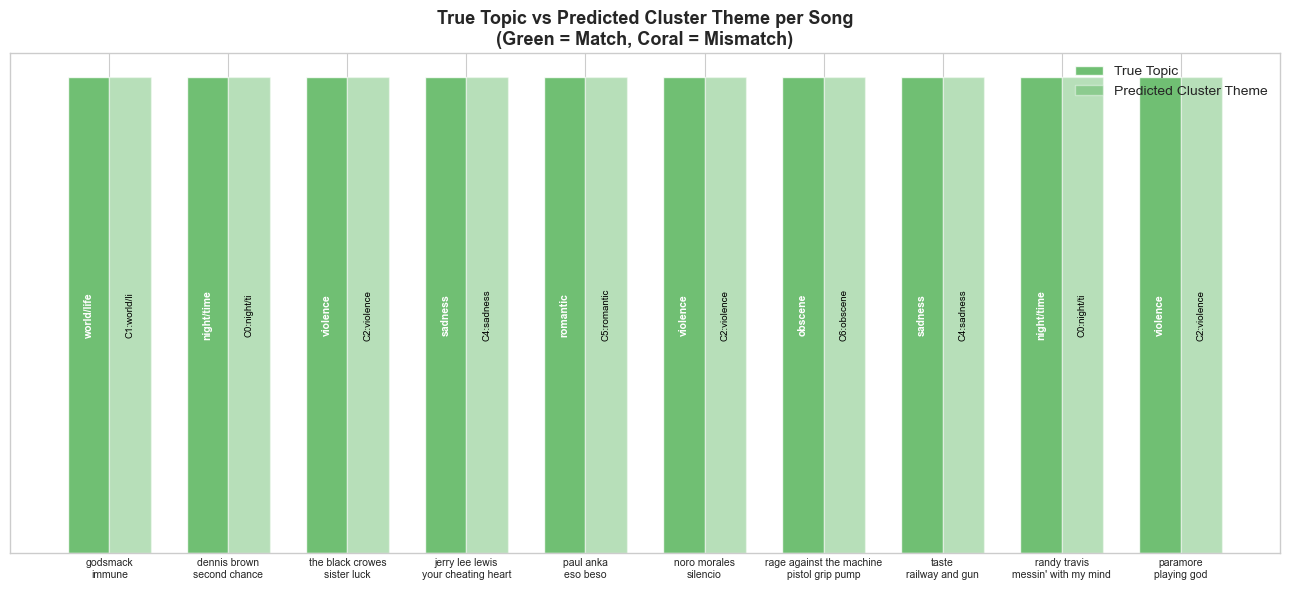

In [ ]:
# Lets visualize our evaluation results 

# True topic vs predicted cluster theme for each song
fig, ax = plt.subplots(figsize=(13, 6))

songs = [f"{row['artist_name']}\n{row['track_name']}"
         for _, row in df_test_result.iterrows()]

true_topics = df_test_result['topic'].tolist()
cluster_themes = df_test_result['cluster_dominant_theme'].tolist()
clusters = df_test_result['predicted_cluster'].tolist()

x = np.arange(len(songs))
width = 0.35

# Coloring bars by match: green for match, coral for mismatch
colors_true = []
colors_pred = []
for t, c in zip(true_topics, cluster_themes):
    is_match = t.lower() in c.lower() or c.lower() in t.lower()
    colors_true.append('#4CAF50' if is_match else '#FF7043')
    colors_pred.append('#4CAF50' if is_match else '#FF7043')

bars1 = ax.bar(x - width/2, [1]*len(songs), width,
               label='True Topic', color=colors_true,
               alpha=0.8, edgecolor='white')
bars2 = ax.bar(x + width/2, [1]*len(songs), width,
               label='Predicted Cluster Theme', color=colors_pred,
               alpha=0.4, edgecolor='white')

# Adding text labels on bars
for i, (bar, topic) in enumerate(zip(bars1, true_topics)):
    ax.text(bar.get_x() + bar.get_width()/2, 0.5,
            topic, ha='center', va='center',
            fontsize=7.5, fontweight='bold', rotation=90, color='white')

for i, (bar, theme, cluster) in enumerate(zip(bars2, cluster_themes, clusters)):
    ax.text(bar.get_x() + bar.get_width()/2, 0.5,
            f"C{cluster}:{theme[:8]}", ha='center', va='center',
            fontsize=7, rotation=90, color='black')

ax.set_xticks(x)
ax.set_xticklabels(songs, fontsize=7.5)
ax.set_yticks([])
ax.set_title('True Topic vs Predicted Cluster Theme per Song\n(Green = Match, Coral = Mismatch)',
             fontsize=13, fontweight='bold')
ax.legend(loc='upper right')

plt.tight_layout()

plt.show()

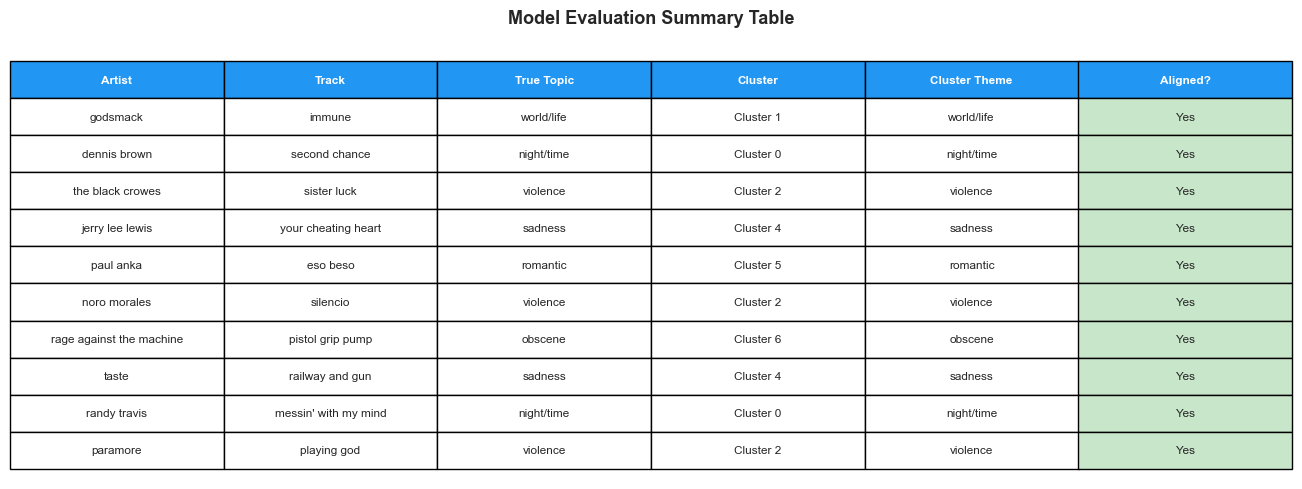

In [ ]:
# Summary table as a heatmap-style visual
fig, ax = plt.subplots(figsize=(13, 5))
ax.axis('off')

table_data = []
col_labels = ['Artist', 'Track', 'True Topic', 'Cluster', 'Cluster Theme', 'Aligned?']

for _, row in df_test_result.iterrows():
    true_topic = str(row['topic'])
    cluster_theme = str(row['cluster_dominant_theme'])
    is_match = true_topic.lower() in cluster_theme.lower() or \
               cluster_theme.lower() in true_topic.lower()

    table_data.append([
        row['artist_name'],
        row['track_name'],
        true_topic,
        f"Cluster {row['predicted_cluster']}",
        cluster_theme,
        'Yes' if is_match else 'No'
    ])

table = ax.table(
    cellText=table_data,
    colLabels=col_labels,
    cellLoc='center',
    loc='center'
)

table.auto_set_font_size(False)
table.set_fontsize(8.5)
table.scale(1.2, 2.0)

# Coloring the header row
for j in range(len(col_labels)):
    table[0, j].set_facecolor('#2196F3')
    table[0, j].set_text_props(color='white', fontweight='bold')

# Coloring the aligned column
for i in range(1, len(table_data)+1):
    val = table_data[i-1][5]
    if val == 'Yes':
        table[i, 5].set_facecolor('#C8E6C9')
    else:
        table[i, 5].set_facecolor('#FFCCBC')

plt.title('Model Evaluation Summary Table',
          fontsize=13, fontweight='bold', pad=20)
plt.tight_layout()

plt.show()

##  Generate Music Recommendations

Now that we have evaluated the model we generate the actual recommendations. For each test song we find 5 songs from the same cluster in the training set and recommend them to the user.

The recommendations are grounded in lyrical content songs in the same cluster share similar lyrical DNA across all 17 features.

In [62]:
#Generating our music recommendations

all_recommendations = []

print("PERSONALIZED MUSIC RECOMMENDATIONS")
print("=" * 70)

for _, test_row in df_test_result.iterrows():
    cluster_id = int(test_row['predicted_cluster'])
    top_themes = cluster_profiles.loc[cluster_id].nlargest(3).index.tolist()

    same_cluster = df_train_labeled[df_train_labeled['cluster'] == cluster_id]
    n_recs = min(5, len(same_cluster))
    recommended = same_cluster[['artist_name', 'track_name', 'genre']].sample(
        n_recs, random_state=42
    )

    print()
    print(f"  Because you listened to:")
    print(f"  {test_row['artist_name']} — {test_row['track_name']} ({test_row['genre']})")
    print(f"  True topic: {test_row['topic']}  |  "
          f"Cluster {cluster_id}  |  "
          f"Top themes: {', '.join(top_themes)}")
    print()
    print(f"  We recommend:")
    for _, rec in recommended.iterrows():
        print(f"    → {str(rec['artist_name']):<28} "
              f"— {str(rec['track_name']):<30} "
              f"({rec['genre']})")
        all_recommendations.append({
            'listened_to_artist':  test_row['artist_name'],
            'listened_to_song':    test_row['track_name'],
            'listened_to_genre':   test_row['genre'],
            'true_topic':          test_row['topic'],
            'cluster':             cluster_id,
            'cluster_themes':      ', '.join(top_themes),
            'recommended_artist':  rec['artist_name'],
            'recommended_song':    rec['track_name'],
            'recommended_genre':   rec['genre']
        })
    print()
  

print()
print("=" * 70)
print(f"Total recommendations generated: {len(all_recommendations)}")

PERSONALIZED MUSIC RECOMMENDATIONS

  Because you listened to:
  godsmack — immune (rock)
  True topic: world/life  |  Cluster 1  |  Top themes: world/life, communication, sadness

  We recommend:
    → dolly parton                 — wildflowers                    (country)
    → the cranberries              — dreaming my dreams             (pop)
    → rebelution                   — take on anything               (reggae)
    → chicago                      — will you still love me?        (rock)
    → willie nelson                — wonderful future               (country)


  Because you listened to:
  dennis brown — second chance (reggae)
  True topic: night/time  |  Cluster 0  |  Top themes: night/time, communication, sadness

  We recommend:
    → herbs                        — home grown                     (reggae)
    → lightnin' hopkins            — so long baby                   (country)
    → pet shop boys                — always on my mind              (pop)
    → ashford & 

In [64]:
# Saving all our output to a CSV for easy sharing and analysis

# Saving test songs with cluster assignments and ground truth
df_test_result.to_csv(
    '/Users/sa03/Desktop/Music Recommendation Algorithm/Dataset/music_rec/test_songs_with_clusters.csv',
    index=True
)
print("Saved: test_songs_with_clusters.csv")

# Saving the full recommendations table
df_recommendations = pd.DataFrame(all_recommendations)
df_recommendations.to_csv(
    '/Users/sa03/Desktop/Music Recommendation Algorithm/Dataset/music_rec/recommendations.csv',
    index=False
)
print("Saved: recommendations.csv")

print()
print("Final recommendations table:")
print()
print(df_recommendations[[
    'listened_to_artist',
    'listened_to_song',
    'true_topic',
    'cluster',
    'recommended_artist',
    'recommended_song',
    'recommended_genre'
]].to_string(index=False))

Saved: test_songs_with_clusters.csv
Saved: recommendations.csv

Final recommendations table:

      listened_to_artist     listened_to_song true_topic  cluster      recommended_artist                        recommended_song recommended_genre
                godsmack               immune world/life        1            dolly parton                             wildflowers           country
                godsmack               immune world/life        1         the cranberries                      dreaming my dreams               pop
                godsmack               immune world/life        1              rebelution                        take on anything            reggae
                godsmack               immune world/life        1                 chicago                 will you still love me?              rock
                godsmack               immune world/life        1           willie nelson                        wonderful future           country
            dennis